### Import data

In [110]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats

from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV


In [111]:
# data types for read_csv: client_catg = category, disrict = category, creation_date = parse date,
# tarif_type_mode = category, has_multi_invoice_same_day_nanmax = category, region = category
dtypeToStr={'client_catg': 'str', 'disrict': 'str', 'tarif_type_mode': 'str', 'has_multi_invoice_same_day_nanmax': 'str', 'region': 'str'}
train_res = pd.read_csv('data/created_train_res.csv', dtype=dtypeToStr, parse_dates=['creation_date'], dayfirst=True, low_memory=False)
val = pd.read_csv('data/created_val.csv', dtype=dtypeToStr, parse_dates=['creation_date'], dayfirst=True, low_memory=False)
test = pd.read_csv(f'data/created_test.csv', dtype=dtypeToStr, parse_dates=['creation_date'], dayfirst=True, low_memory=False)

sample_submission = pd.read_csv(f'results/SampleSubmission.csv', low_memory=False)


In [112]:
print(train_res.shape, val.shape, test.shape)

(12106, 18) (27099, 18) (58069, 17)


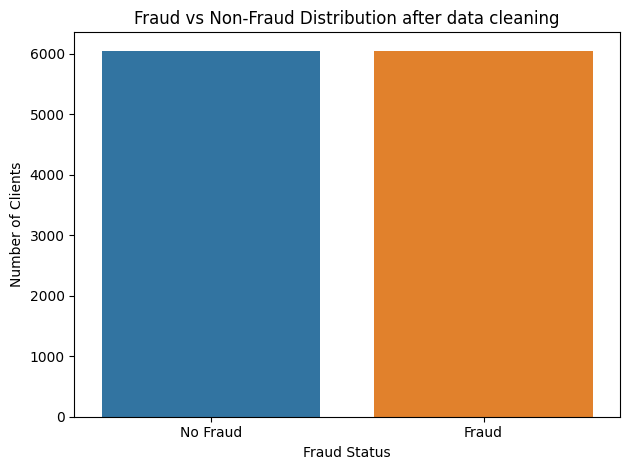

In [113]:
ax = sns.countplot(x="target",
              data=train_res)

ax.set_xlabel("Fraud Status")
ax.set_ylabel("Number of Clients")
ax.set_xticklabels(["No Fraud", "Fraud"])

plt.title("Fraud vs Non-Fraud Distribution after data cleaning")
plt.tight_layout()
plt.show()

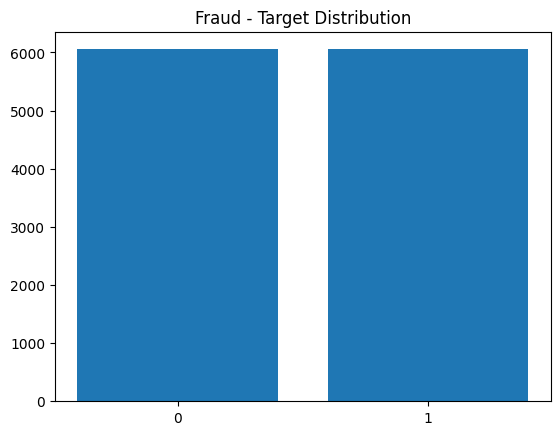

In [114]:
fraudactivities = train_res.groupby(['target'])['client_id'].count()
plt.bar(x=fraudactivities.index, height=fraudactivities.values, tick_label = [0,1])
plt.title('Fraud - Target Distribution')
plt.show()

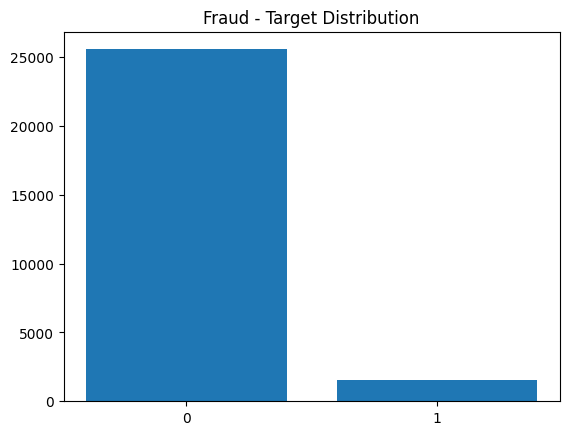

In [115]:
fraudactivities = val.groupby(['target'])['client_id'].count()
plt.bar(x=fraudactivities.index, height=fraudactivities.values, tick_label = [0,1])
plt.title('Fraud - Target Distribution')
plt.show()

##### drop columns not needed for modelling (on all data sets)

In [116]:
client_id_train_res = train_res['client_id']
client_id_val = val['client_id']
client_id_test = test['client_id']

drop_columns = ['client_id', 'creation_date', 'disrict']
for col in drop_columns:
    if col in train_res.columns:
        train_res.drop([col], axis=1, inplace=True)
    if col in val.columns:
        val.drop([col], axis=1, inplace=True)
    if col in test.columns:
        test.drop([col], axis=1, inplace=True)

In [117]:
X_train = train_res.drop('target', axis=1)
y_train = train_res['target']

cat_cols = X_train.select_dtypes(include=['category']).columns.tolist()
cbc = CatBoostClassifier(random_seed=42, verbose=0)
cbc.fit(X_train, y_train, cat_features=cat_cols)

y_train_preds = cbc.predict(X_train)
y_train_preds_proba = cbc.predict_proba(X_train)[:, 1]
train_auc_score = roc_auc_score(y_train, y_train_preds_proba)

X_test_preds = cbc.predict(test)
X_test_preds_proba = cbc.predict_proba(test)[:, 1]
#X_test_auc_score = roc_auc_score(y_test, X_test_preds)

X_val = val.drop('target', axis=1)
y_val = val['target']

val_preds = cbc.predict(X_val)
val_preds_proba = cbc.predict_proba(X_val)[:, 1]
val_auc_score = roc_auc_score(y_val, val_preds_proba)

In [118]:
print("X_train AROC: {:.2f}".format(train_auc_score))
print("classification_report for training data:")
print(classification_report(y_train, y_train_preds))
print('---'*10)
print("Validation AROC: {:.2f}".format(val_auc_score))
print("classification_report for validation data:")
print(classification_report(y_val, val_preds))

X_train AROC: 0.89
classification_report for training data:
              precision    recall  f1-score   support

         0.0       0.83      0.75      0.79      6053
         1.0       0.77      0.85      0.81      6053

    accuracy                           0.80     12106
   macro avg       0.80      0.80      0.80     12106
weighted avg       0.80      0.80      0.80     12106

------------------------------
Validation AROC: 0.77
classification_report for validation data:
              precision    recall  f1-score   support

         0.0       0.98      0.64      0.77     25586
         1.0       0.11      0.75      0.19      1513

    accuracy                           0.64     27099
   macro avg       0.54      0.70      0.48     27099
weighted avg       0.93      0.64      0.74     27099



In [119]:
#param_grid = {
#            'iterations': [100, 200],
#            'learning_rate': [0.01, 0.05, 0.1],
#            'depth': [4, 6, 8],
#            'l2_leaf_reg': [1, 3, 5, 10],
#            'subsample': [0.8, 1.0]
#        }

In [120]:
#Best parameters:
#{'depth': 8, 'iterations': 200, 'l2_leaf_reg': 10, 'learning_rate': 0.05, 'subsample': 0.8}
#
#Best AUC Score (CV): 0.7641
#Test-Score: 0.9520
#param_grid = { 
#    'depth': [4, 8, 16],               # Anzahl der Bäume (kleiner halten für GridSearch)
#    'iterations': [200],      # Tiefe der Bäume
#    'l2_leaf_reg': [3, 5, 10],       # Lernrate        
#    'learning_rate': [0.01, 0.05], # Regularisierung
#    'subsample': [0.4, 0.8]             # Daten-Subsampling
#}

In [121]:
#Best parameters:
# depth': 8, 'iterations': 200, 'l2_leaf_reg': 10, 'learning_rate': 0.05, 'subsample': 0.8
#
#Best AUC Score (CV): 0.7641
#Test-Score: 0.9520
param_grid = { 
    'depth': [8],               # Anzahl der Bäume (kleiner halten für GridSearch)
    'iterations': [200],      # Tiefe der Bäume
    'l2_leaf_reg': [10, 15],       # Lernrate        
    'learning_rate': [0.05, 0.1], # Regularisierung
    'subsample': [0.8]             # Daten-Subsampling
}

In [122]:
grid_search = GridSearchCV(
    estimator=cbc,
    param_grid=param_grid,
    cv=3, 
    scoring='roc_auc',  
    n_jobs=-1,
    verbose=1,           # Zeigt den Fortschritt an
    refit=True           # Das beste Modell wird automatisch neu auf den gesamten Trainingsdaten trainiert    
)

# Durchführung der Suche
print("Starte GridSearch...")
grid_search.fit(X_train, y_train)

# Ergebnisse anzeigen
print("\nBest parameters:")
print(grid_search.best_params_)
print(f"\nBest AUC Score (CV): {grid_search.best_score_:.4f}")

# Evaluation des besten Modells auf dem Testset
best_model = grid_search.best_estimator_
test_score = best_model.score(val, val_preds)
print(f"Test-Score: {test_score:.4f}")

Starte GridSearch...
Fitting 3 folds for each of 4 candidates, totalling 12 fits

Best parameters:
{'depth': 8, 'iterations': 200, 'l2_leaf_reg': 10, 'learning_rate': 0.05, 'subsample': 0.8}

Best AUC Score (CV): 0.7592
Test-Score: 0.9372


In [123]:
features = list(X_train.columns)
fi_model = pd.DataFrame({'feature': features,
                   'importance': best_model.feature_importances_}).\
                    sort_values('importance', ascending = False)
fi_model
#	feature	importance
#2	1transactions_count	15.266573
#1	region	13.928104
#6	consumption_per_month_scaled_nanstd	9.384658
#3	gap_days_nanstd	8.777897
#9	reading_remarque_nanstd	8.110481
#7	active_nanmean	7.986021
#4	consumption_per_month_nanstd	7.232910
#11	index_diff_nanstd	7.224489
#10	tarif_type_mode	5.046731
#12	has_multi_invoice_same_day_nanmax	4.834114


,feature,importance
2,1transactions_count,14.327972
1,region,13.125516
3,gap_days_nanstd,9.613904
9,reading_remarque_nanstd,9.007816
7,active_nanmean,8.135370
11,index_diff_nanstd,7.436423
6,consumption_per_month_scaled_nanstd,7.391677
4,consumption_per_month_nanstd,7.339262
10,tarif_type_mode,5.805529
12,has_multi_invoice_same_day_nanmax,4.945612


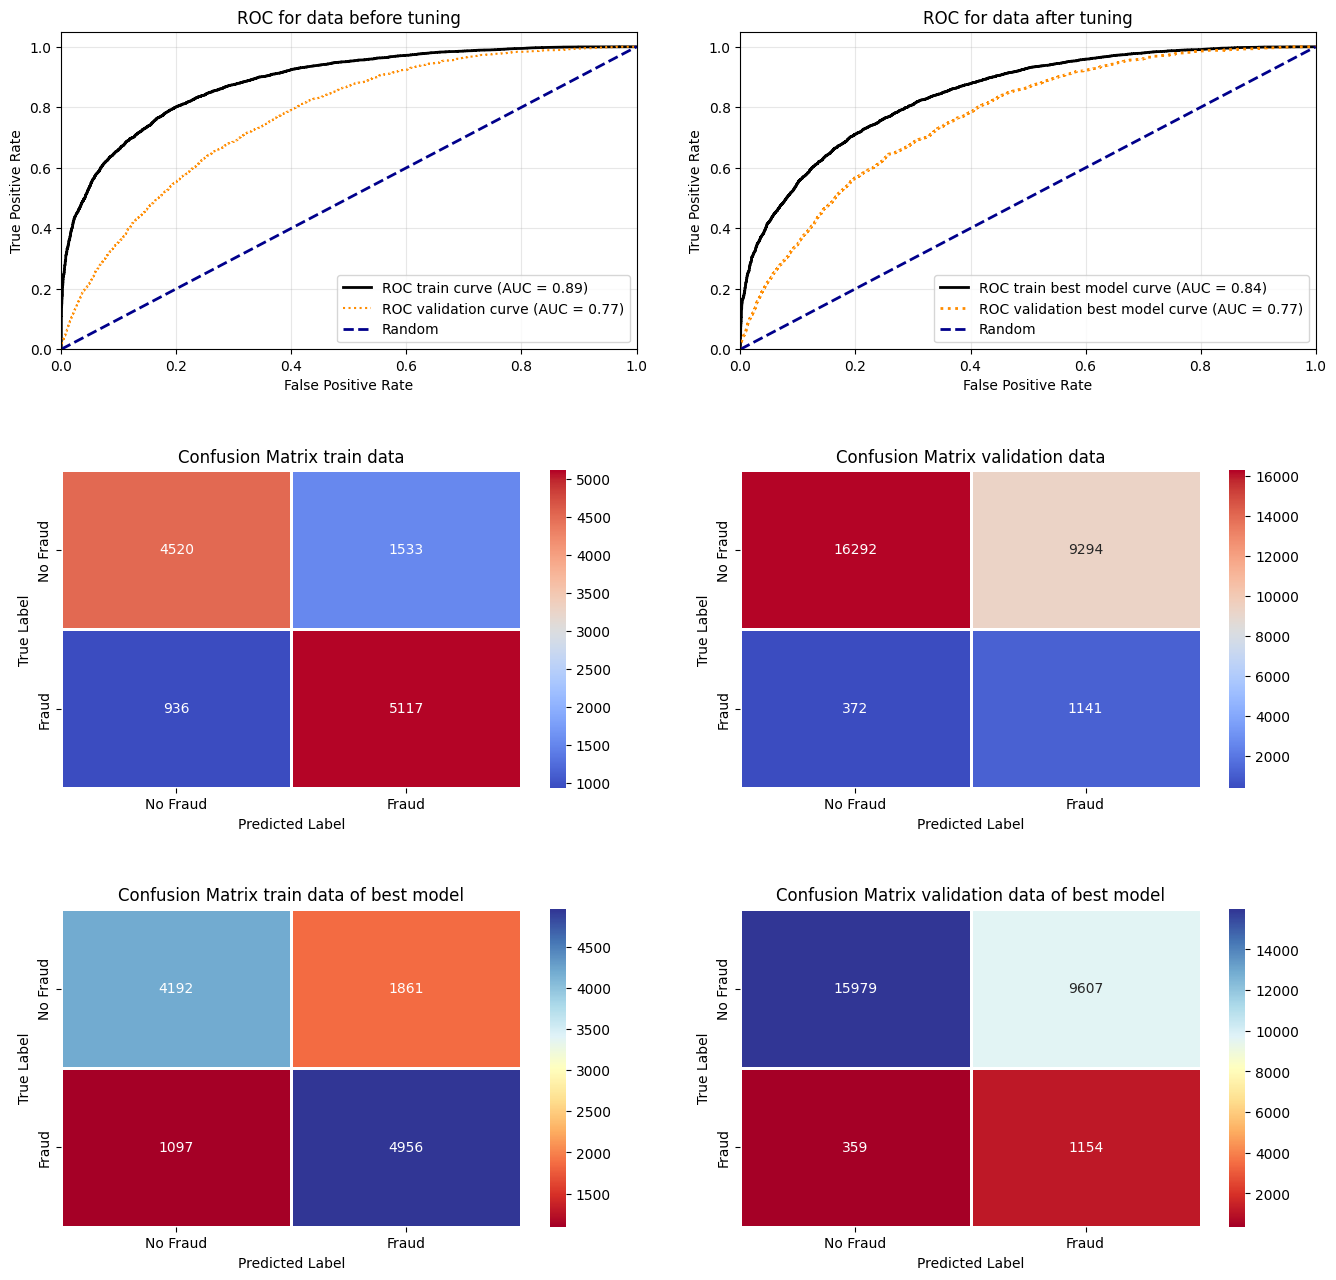

In [124]:
# prediction

# start model
y_train_preds_proba = cbc.predict_proba(X_train)[:, 1]
val_preds_proba = cbc.predict_proba(X_val)[:, 1]
train_preds = cbc.predict(X_train)
val_preds = cbc.predict(X_val)

# best model
y_train_preds_proba_bestModel = best_model.predict_proba(X_train)[:, 1]
val_preds_proba_bestModel = best_model.predict_proba(X_val)[:, 1]
train_preds_bestModel = best_model.predict(X_train)
val_preds_bestModel = best_model.predict(X_val)

#threshold = 0.4   # example
#y_train_preds_proba_bestModel = (y_train_preds_proba_bestModel >= threshold)
#val_preds_proba_bestModel = (val_preds_proba_bestModel >= threshold)
#train_preds_bestModel = y_train_preds_proba_bestModel.astype(int)
#val_preds_bestModel = val_preds_proba_bestModel.astype(int)

# 2. AUC Scores berechnen
# start model
fpr_train, tpr_train, treshold_train = roc_curve(y_train, y_train_preds_proba)
train_auc = roc_auc_score(y_train, y_train_preds_proba)

fpr_val, tpr_val, treshold_val = roc_curve(y_val, val_preds_proba)
val_auc = roc_auc_score(y_val, val_preds_proba)

# best model
fpr_train_bestModel, tpr_train_bestModel, treshold_train_bestModel = roc_curve(y_train, y_train_preds_proba_bestModel)
train_auc_bestModel = roc_auc_score(y_train, y_train_preds_proba_bestModel)

fpr_val_bestModel, tpr_val_bestModel, treshold_val_bestModel = roc_curve(y_val, val_preds_proba_bestModel)
val_auc_bestModel = roc_auc_score(y_val, val_preds_proba_bestModel)

# 3. Confusion Matrices berechnen
# start model
cfm_train = confusion_matrix(y_train, train_preds)
cfm_val = confusion_matrix(y_val, val_preds)

# best model
cfm_train_bestModel = confusion_matrix(y_train, train_preds_bestModel)
cfm_val_bestModel = confusion_matrix(y_val, val_preds_bestModel)

fig, axes = plt.subplots(3, 2, figsize=(14, 14))
# Roc curve train data '-', '--', '-.', ':', 'None', ' ', '', 'solid', 'dashed', 'dashdot', 'dotted'
axes[0, 0].plot(fpr_train, tpr_train, color='black', linestyle='-', lw=2, label=f'ROC train curve (AUC = {train_auc_score:.2f})')
axes[0, 0].plot(fpr_val, tpr_val, color='darkorange', linestyle='dotted', label=f'ROC validation curve (AUC = {val_auc_score:.2f})')
#axes[0, 0].plot(fpr_train_bestModel, tpr_train_bestModel, color='darkorange', linestyle='dotted', lw=2, label=f'ROC train best model curve (AUC = {train_auc_bestModel:.2f})')
#axes[0, 0].plot(fpr_val_bestModel, tpr_val_bestModel, color='darkorange', linestyle='dashdot', lw=2, label=f'ROC validation best model curve (AUC = {val_auc_bestModel:.2f})')
axes[0, 0].plot([0, 1], [0, 1], color='darkblue', lw=2, linestyle='--', label='Random')
axes[0, 0].set_xlim([0.0, 1.0])
axes[0, 0].set_ylim([0.0, 1.05])
axes[0, 0].set_xlabel('False Positive Rate')
axes[0, 0].set_ylabel('True Positive Rate')
axes[0, 0].set_title('ROC for data before tuning')
axes[0, 0].legend(loc="lower right")
axes[0, 0].grid(alpha=0.3)

# ROC curve validation data
axes[0, 1].plot(fpr_train_bestModel, tpr_train_bestModel, color='black', linestyle='-', lw=2, label=f'ROC train best model curve (AUC = {train_auc_bestModel:.2f})')
axes[0, 1].plot(fpr_val_bestModel, tpr_val_bestModel, color='darkorange', linestyle='dotted', lw=2, label=f'ROC validation best model curve (AUC = {val_auc_bestModel:.2f})')
axes[0, 1].plot([0, 1], [0, 1], color='darkblue', lw=2, linestyle='--', label='Random')
axes[0, 1].set_xlim([0.0, 1.0])
axes[0, 1].set_ylim([0.0, 1.05])
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].set_title('ROC for data after tuning')
axes[0, 1].legend(loc="lower right")
axes[0, 1].grid(alpha=0.3)

# Confusion matrix train data
sns.heatmap(cfm_train, 
            ax=axes[1, 0], 
            cmap='coolwarm', 
            annot=True, 
            fmt='d', 
            linewidths=1, 
            xticklabels=['No Fraud', 'Fraud'],
            yticklabels=['No Fraud', 'Fraud'])
axes[1, 0].set_title('Confusion Matrix train data')
axes[1, 0].set_xlabel('Predicted Label')
axes[1, 0].set_ylabel('True Label')

# Confusion matrix validation data
sns.heatmap(cfm_val, 
            ax=axes[1, 1], 
            cmap='coolwarm', 
            annot=True, 
            fmt='d', 
            linewidths=1,
            xticklabels=['No Fraud', 'Fraud'],
            yticklabels=['No Fraud', 'Fraud'])
axes[1, 1].set_title('Confusion Matrix validation data')
axes[1, 1].set_xlabel('Predicted Label')
axes[1, 1].set_ylabel('True Label')

# Confusion matrix train data
sns.heatmap(cfm_train_bestModel, 
            ax=axes[2, 0], 
            cmap='RdYlBu', 
            annot=True, 
            fmt='d', 
            linewidths=1, 
            xticklabels=['No Fraud', 'Fraud'],
            yticklabels=['No Fraud', 'Fraud'])
axes[2, 0].set_title('Confusion Matrix train data of best model')
axes[2, 0].set_xlabel('Predicted Label')
axes[2, 0].set_ylabel('True Label')

# Confusion matrix validation data
sns.heatmap(cfm_val_bestModel, 
            ax=axes[2, 1], 
            cmap='RdYlBu', 
            annot=True, 
            fmt='d', 
            linewidths=1,
            xticklabels=['No Fraud', 'Fraud'],
            yticklabels=['No Fraud', 'Fraud'])
axes[2, 1].set_title('Confusion Matrix validation data of best model')
axes[2, 1].set_xlabel('Predicted Label')
axes[2, 1].set_ylabel('True Label')

plt.tight_layout(rect=[0, 0, 1, 0.96], pad=3.0, h_pad=4.0, w_pad=3.0)
plt.show()

# best model dendency to predict more positiv than the first model

In [125]:
preds = best_model.predict_proba(test)[:,1]
preds = pd.DataFrame(preds, columns=['target'])
preds.head()

,target
0,0.589977
1,0.729823
2,0.383126
3,0.433502
4,0.588806


In [126]:
submission = pd.DataFrame(
    {
        'client_id': client_id_test,
        'target': preds['target']
    }
)

submission.head()

,client_id,target
0,test_Client_0,0.589977
1,test_Client_1,0.729823
2,test_Client_10,0.383126
3,test_Client_100,0.433502
4,test_Client_1000,0.588806


In [127]:
submission.tail(20)

,client_id,target
58049,test_Client_9981,0.335836
58050,test_Client_9982,0.605907
58051,test_Client_9983,0.821338
58052,test_Client_9984,0.245762
58053,test_Client_9985,0.783841
58054,test_Client_9986,0.387380
58055,test_Client_9987,0.577845
58056,test_Client_9988,0.640015
58057,test_Client_9989,0.327387
58058,test_Client_999,0.416966


In [128]:
submission.to_csv('results/submission_CatBoost.csv', index=False)